In [51]:
# importation of libraries
import  pandas as pd
import  numpy as np
import  matplotlib.pyplot as plt
import  seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder


In [52]:
# load the dataset
df=pd.read_csv("Train.csv")
df

,BCT_CODBUR,CTR_MATFIS,CTR_CATEGO_X,FJU_CODFJU,CTR_CESSAT,ACT_CODACT,CTR_OBLDIR,CTR_OBLACP,CTR_OBLRES,CTR_OBLFOP,...,target,FAC_MNTPRI_F,FAC_MFODEC_F,FAC_MNTDCO_F,FAC_MNTTVA_F,FAC_MNTPRI_C,FAC_MFODEC_C,FAC_MNTDCO_C,FAC_MNTTVA_C,id
0,44,6210,C,99,0,3707,4,2,2,2,...,16.639203,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id17437
1,401,14383,M,22,0,6105,4,2,2,2,...,17.827703,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id5086
2,243,11555,M,23,0,5751,4,2,2,2,...,15.473503,25387000.0,0.0,0.0,4571280.0,NaN,NaN,NaN,NaN,train_id1443
3,72,6175,C,99,0,4402,4,2,2,2,...,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id15469
4,42,1417,M,23,0,6302,4,2,2,2,...,14.286244,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id14368
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21290,47,6766,M,22,0,4203,4,2,2,2,...,16.544842,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id7173
21291,113,15006,M,21,0,5703,4,2,2,3,...,17.651115,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id12850
21292,700,2429,M,22,0,4218,4,2,2,2,...,18.018778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id4062
21293,248,1323,M,22,0,3201,4,2,2,2,...,15.521108,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,train_id4052


# DATA CLEANING AND EDA

In [53]:
# data information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21295 entries, 0 to 21294
Columns: 121 entries, BCT_CODBUR to id
dtypes: float64(103), int64(16), object(2)
memory usage: 19.7+ MB


In [54]:
# statistical summary of the dataset
df.describe()

,BCT_CODBUR,CTR_MATFIS,FJU_CODFJU,CTR_CESSAT,ACT_CODACT,CTR_OBLDIR,CTR_OBLACP,CTR_OBLRES,CTR_OBLFOP,CTR_OBLTFP,...,RES_ANNIMP,target,FAC_MNTPRI_F,FAC_MFODEC_F,FAC_MNTDCO_F,FAC_MNTTVA_F,FAC_MNTPRI_C,FAC_MFODEC_C,FAC_MNTDCO_C,FAC_MNTTVA_C
count,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,21295.000000,...,21295.000000,21295.000000,1.820000e+03,1.820000e+03,1.820000e+03,1.820000e+03,2.113000e+03,2.113000e+03,2.113000e+03,2.113000e+03
mean,214.935807,7797.448697,59.580888,0.048509,4821.595445,4.454191,1.959850,1.977319,1.928105,1.949096,...,2014.508852,11.780084,9.471275e+09,6.632605e+06,9.306873e+04,4.903870e+08,8.420356e+08,1.489097e+06,3.191820e+04,1.386915e+08
std,162.992837,4484.430937,38.542427,0.228200,1168.628546,1.205500,0.196316,0.154462,0.263361,0.221933,...,1.332947,7.085772,1.297572e+11,2.091579e+08,3.596381e+06,4.739676e+09,4.107717e+09,1.733094e+07,7.106121e+05,7.148914e+08
min,9.000000,1.000000,10.000000,0.000000,1002.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,2013.000000,0.000000,2.173000e+04,0.000000e+00,0.000000e+00,0.000000e+00,4.910000e+02,0.000000e+00,0.000000e+00,0.000000e+00
25%,92.000000,3944.000000,22.000000,0.000000,4203.000000,4.000000,2.000000,2.000000,2.000000,2.000000,...,2013.000000,0.000000,3.024577e+07,0.000000e+00,0.000000e+00,4.360140e+06,1.906574e+07,0.000000e+00,0.000000e+00,2.927028e+06
50%,182.000000,7817.000000,23.000000,0.000000,4417.000000,4.000000,2.000000,2.000000,2.000000,2.000000,...,2014.000000,14.981121,1.997162e+08,0.000000e+00,0.000000e+00,2.989651e+07,5.594731e+07,0.000000e+00,0.000000e+00,8.642968e+06
75%,254.000000,11695.500000,99.000000,0.000000,6102.000000,4.000000,2.000000,2.000000,2.000000,2.000000,...,2015.000000,16.625623,9.257110e+08,0.000000e+00,0.000000e+00,1.426512e+08,2.707424e+08,0.000000e+00,0.000000e+00,4.414594e+07
max,700.000000,15603.000000,99.000000,2.000000,8999.000000,9.000000,2.000000,5.000000,5.000000,3.000000,...,2018.000000,23.591334,3.414507e+12,8.897885e+09,1.529912e+08,1.608777e+11,8.351128e+10,4.044067e+08,2.614500e+07,1.352152e+10


In [55]:
# shape of the dataset
df.shape

(21295, 121)

In [56]:
# columns datatypes
df.dtypes

BCT_CODBUR        int64
CTR_MATFIS        int64
CTR_CATEGO_X     object
FJU_CODFJU        int64
CTR_CESSAT        int64
                 ...   
FAC_MNTPRI_C    float64
FAC_MFODEC_C    float64
FAC_MNTDCO_C    float64
FAC_MNTTVA_C    float64
id               object
Length: 121, dtype: object

In [57]:
# duplicate values
df.duplicated().sum()/len(df)*100

np.float64(0.0)

In [58]:
# missing values
df.isnull().sum()/len(df)*100

BCT_CODBUR       0.000000
CTR_MATFIS       0.000000
CTR_CATEGO_X     0.000000
FJU_CODFJU       0.000000
CTR_CESSAT       0.000000
                  ...    
FAC_MNTPRI_C    90.077483
FAC_MFODEC_C    90.077483
FAC_MNTDCO_C    90.077483
FAC_MNTTVA_C    90.077483
id               0.000000
Length: 121, dtype: float64

In [59]:
# colums with more than 50% missing values
missing_pct = (df.isnull().sum() / len(df)) * 100

print(missing_pct[missing_pct > 50])


ADB_MNTORD      74.843860
SND_MNTPRD_I    82.629725
SND_MNTTVA_I    82.629725
SND_MNTDRC_I    82.629725
SND_MNTAVA_I    82.629725
SND_MNTTAX_I    82.629725
SND_MNTPAY_I    82.629725
SND_MNTAIR_I    82.629725
SND_MNTPRD_E    94.219300
SND_MNTTVA_E    94.219300
SND_MNTDRC_E    94.219300
SND_MNTAVA_E    94.219300
SND_MNTTAX_E    94.219300
SND_MNTPAY_E    94.219300
SND_MNTAIR_E    94.219300
SND_MNTPRD_A    86.386476
SND_MNTTVA_A    86.386476
SND_MNTDRC_A    86.386476
SND_MNTAVA_A    86.386476
SND_MNTTAX_A    86.386476
SND_MNTPAY_A    86.386476
SND_MNTAIR_A    86.386476
FAC_MNTPRI_F    91.453393
FAC_MFODEC_F    91.453393
FAC_MNTDCO_F    91.453393
FAC_MNTTVA_F    91.453393
FAC_MNTPRI_C    90.077483
FAC_MFODEC_C    90.077483
FAC_MNTDCO_C    90.077483
FAC_MNTTVA_C    90.077483
dtype: float64


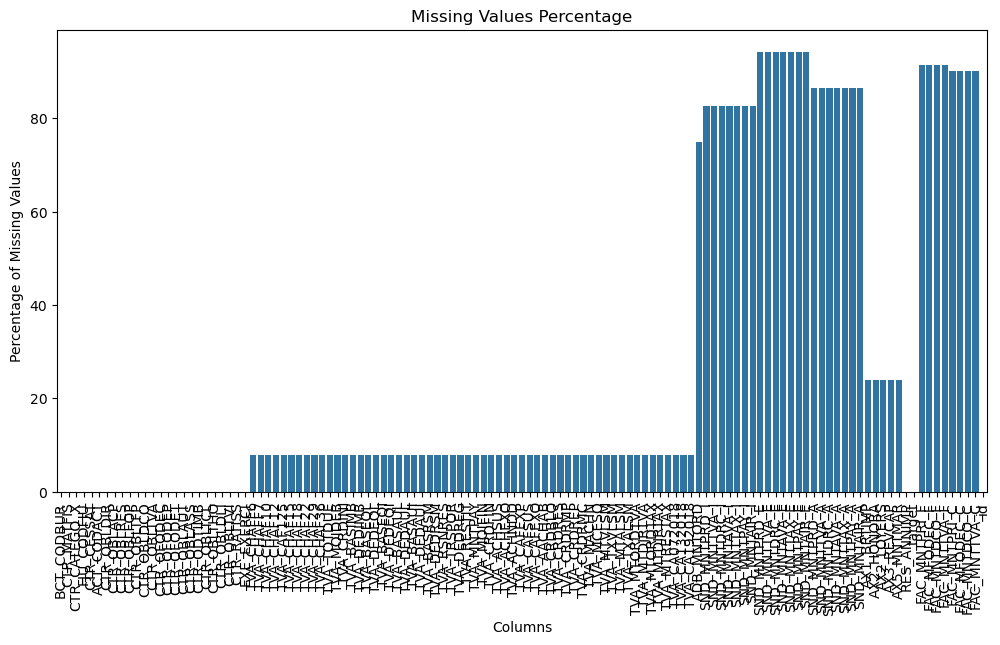

In [60]:
plt.figure(figsize=(12, 6))
plt.title('Missing Values Percentage')
sns.barplot(x=missing_pct.index, y=missing_pct.values)
plt.xlabel('Columns')
plt.ylabel('Percentage of Missing Values')
plt.xticks(rotation=90)
plt.show()

In [61]:
df.drop(missing_pct[missing_pct > 50].index, axis=1, inplace=True)

In [62]:
# filling missing values with mean for numerical columns
# filling missing values for categorical columns with  unknown
missing_cols = df.columns[df.isnull().any()]

for col in missing_cols:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna('Unknown')
    else:
        df[col] = df[col].fillna(df[col].mean())

In [63]:
# numerical values and categorical values
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df.select_dtypes(include=['object']).columns
print("Numerical Columns:", numerical_cols)
print("Categorical Columns:", categorical_cols)

Numerical Columns: Index(['BCT_CODBUR', 'CTR_MATFIS', 'FJU_CODFJU', 'CTR_CESSAT', 'ACT_CODACT',
       'CTR_OBLDIR', 'CTR_OBLACP', 'CTR_OBLRES', 'CTR_OBLFOP', 'CTR_OBLTFP',
       'CTR_OBLDCO', 'CTR_OBLTVA', 'CTR_OFODEC', 'CTR_OFODEP', 'CTR_OFODET',
       'CTR_OBLAUT', 'CTR_OBLASS', 'CTR_ODTIMB', 'CTR_OBLTCL', 'CTR_OBLTHO',
       'CTR_OBLDLI', 'CTR_OBLTVI', 'CTR_RATISS', 'EXE_EXERCI', 'TVA_CHAFF6',
       'TVA_CHAFF7', 'TVA_CHAF10', 'TVA_CHAF12', 'TVA_CAF125', 'TVA_CHAF15',
       'TVA_CHAF18', 'TVA_CHAF22', 'TVA_CHAF29', 'TVA_CHAF36', 'TVA_TOTDUE',
       'TVA_MOIDEB', 'TVA_CRDINI', 'TVA_BASIMB', 'TVA_DEDIMB', 'TVA_BASEQL',
       'TVA_DEDEQL', 'TVA_BASEQI', 'TVA_DEDEQI', 'TVA_BASAUL', 'TVA_DEDAUL',
       'TVA_BASAUI', 'TVA_DEDAUI', 'TVA_BASRSM', 'TVA_DEDRSM', 'TVA_RSNRES',
       'TVA_TRSPOR', 'TVA_DEDREG', 'TVA_RESTIT', 'TVA_MNTPAY', 'TVA_MOIFIN',
       'TVA_CRDFIN', 'TVA_ACHSUS', 'TVA_ACHEXO', 'TVA_ACHNDD', 'TVA_CAFEXP',
       'TVA_CAFSUS', 'TVA_CAFEXO', 'TVA_AACHAB', 'TVA_CRD

# VISUALIZATION

## numerical distribution 

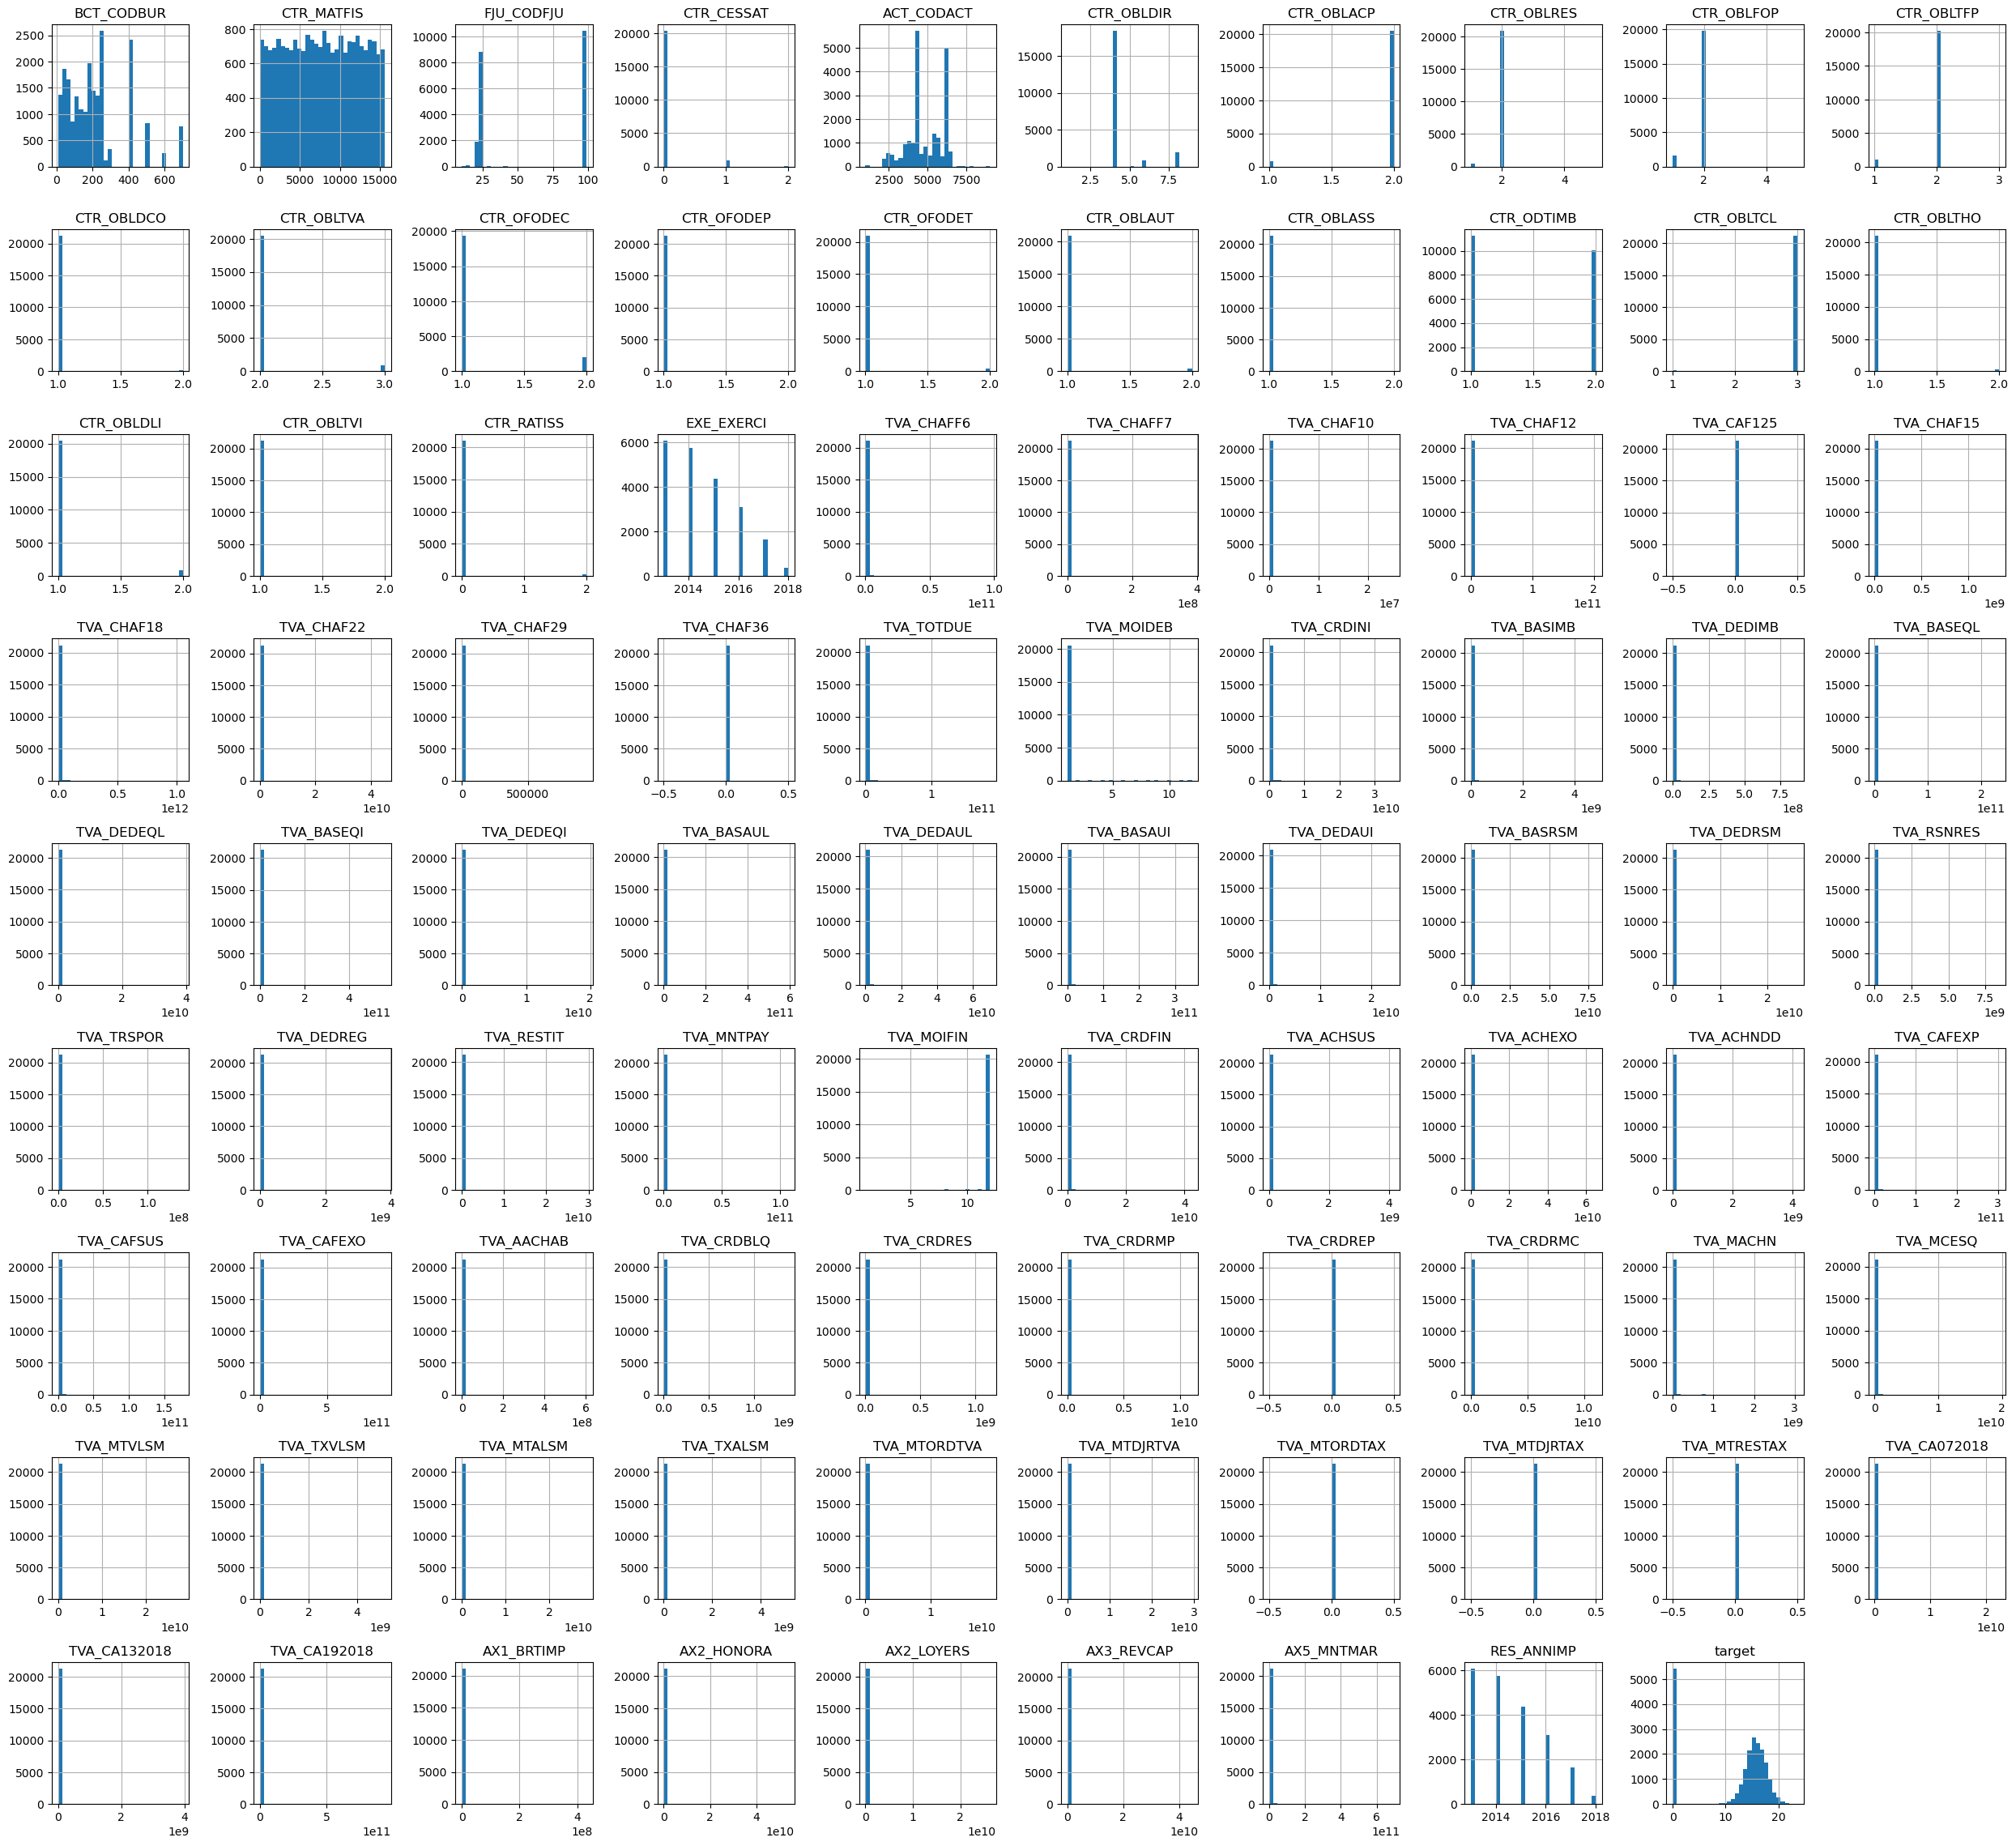

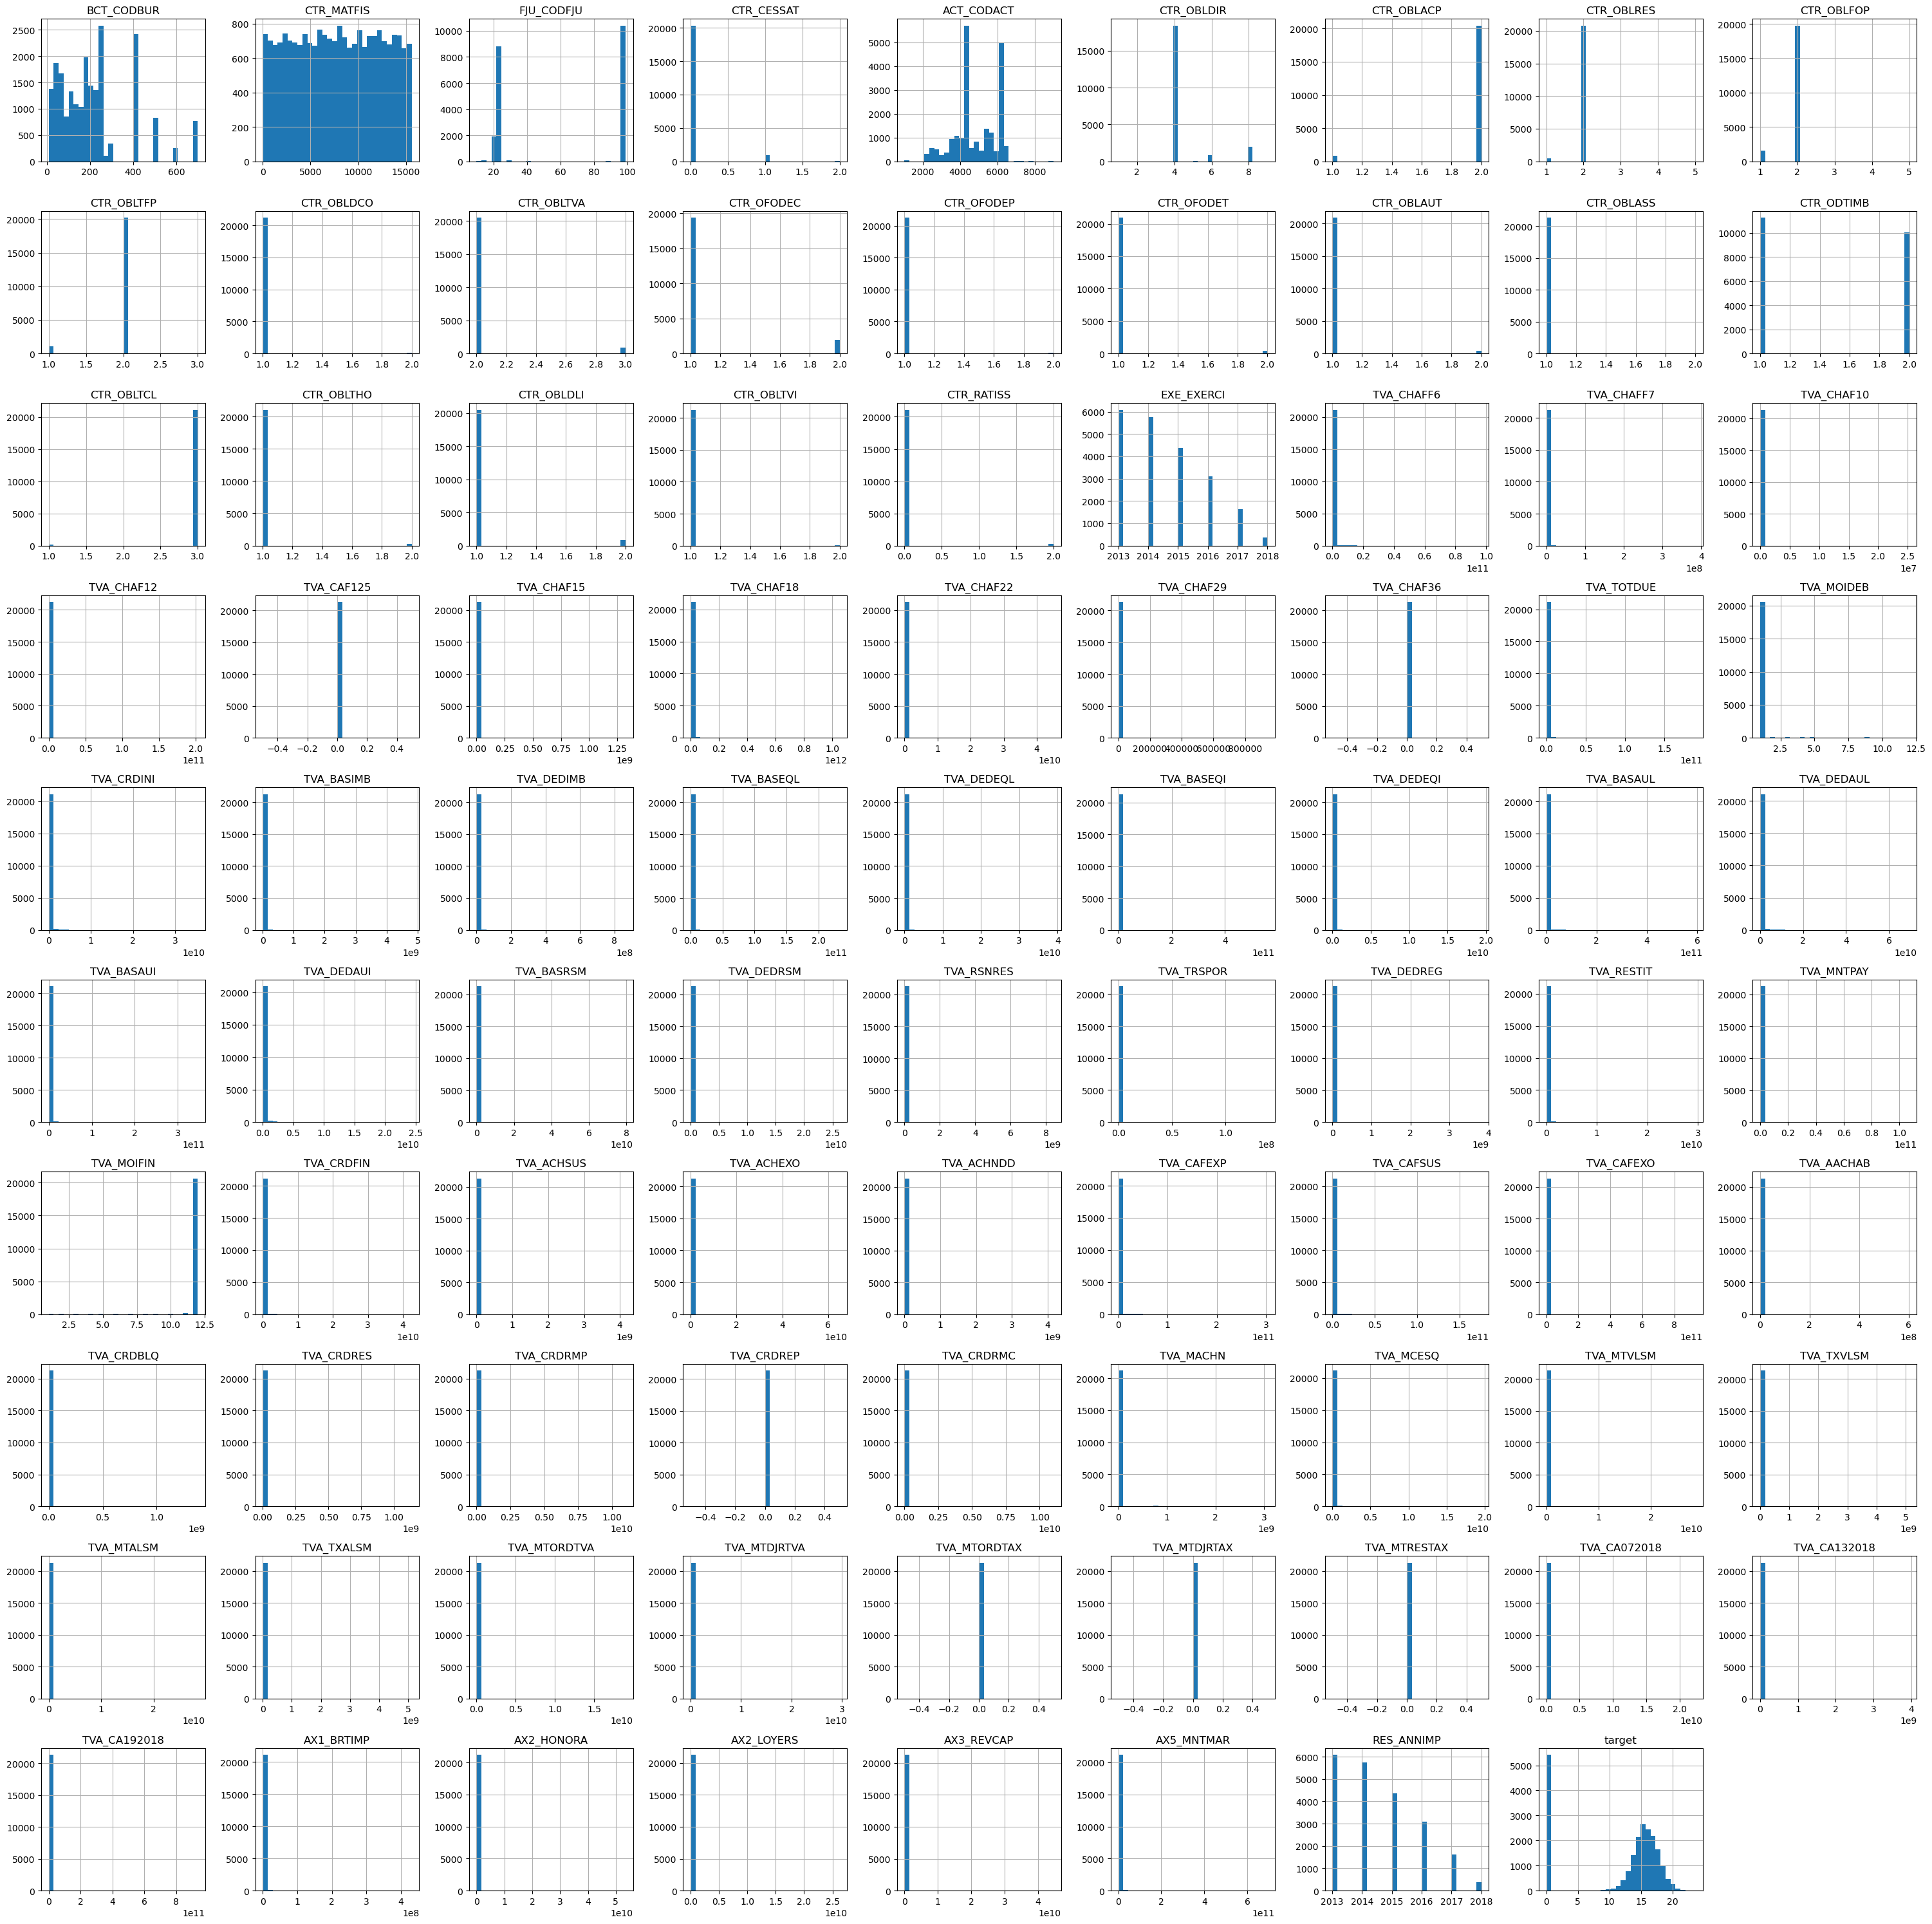

In [64]:
df.hist(
    figsize=(25, 25),
    bins=30,
    layout=(10, 10)  # adjust based on number of columns
)

plt.tight_layout()
plt.show()
df.select_dtypes(include=['int64', 'float64']).hist(
    figsize=(30, 30),
    bins=30
)

plt.tight_layout()
plt.show()

## Target Variable Distribution

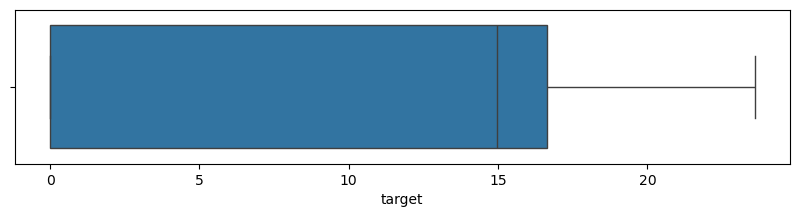

In [65]:
plt.figure(figsize=(10,2))
sns.boxplot(x=df['target'])
plt.show()

## Correlation Heatmap

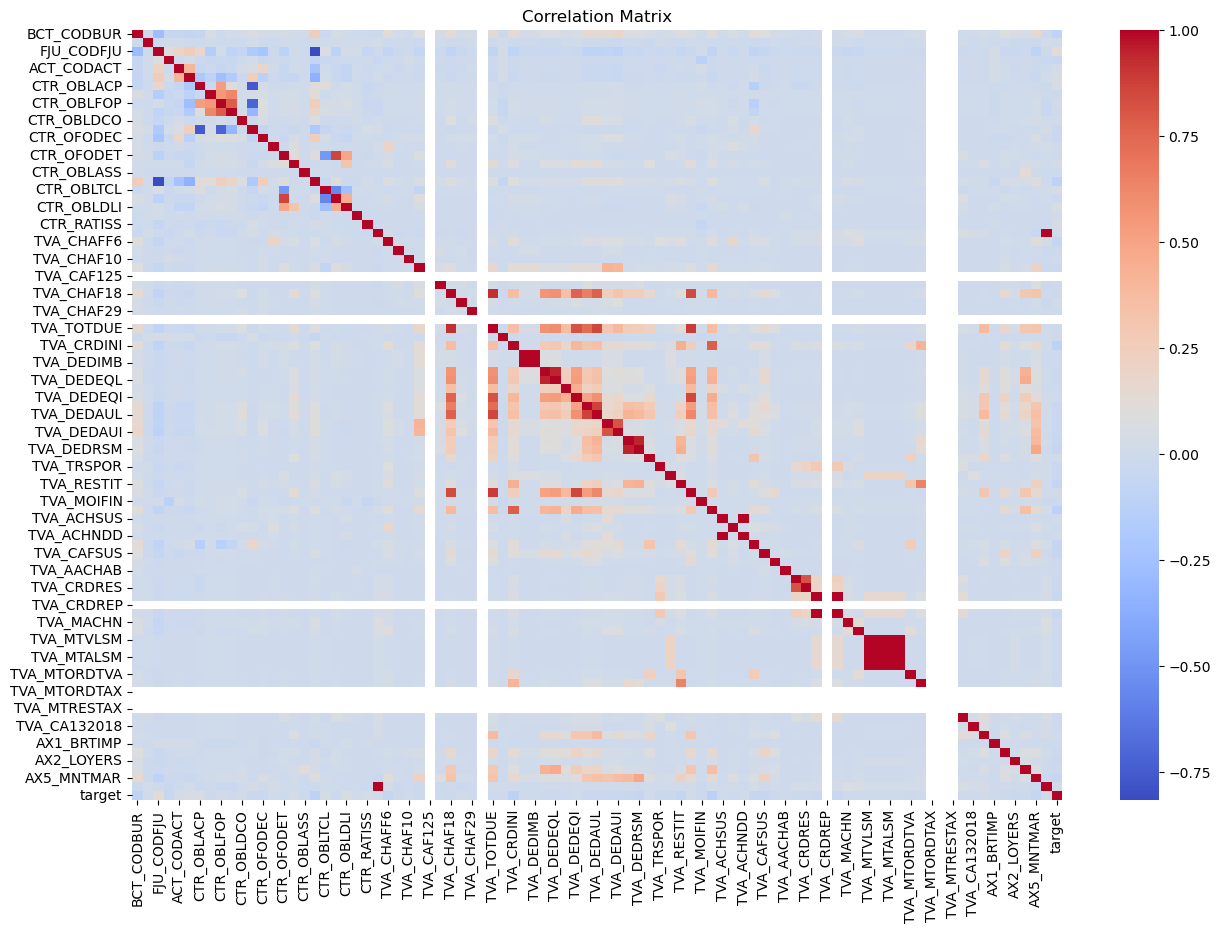

In [66]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

## outlier detection 

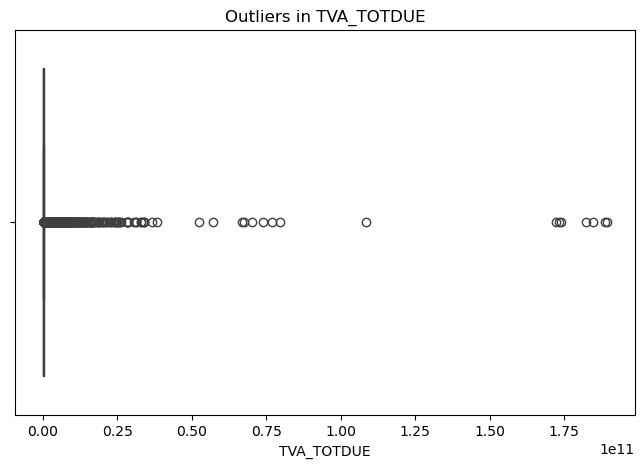

In [67]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['TVA_TOTDUE'])
plt.title('Outliers in TVA_TOTDUE')
plt.show()

# FEATURE ENGENEERING

In [68]:
def engineer_features(df):
    # Tax compliance ratios
    df['TVA_COMPLIANCE_RATIO'] = df['TVA_TOTDUE'] / (df['TVA_CHAFF6'] + 1)
    df['DEDUCTION_RATIO'] = (df['TVA_DEDIMB'] + df['TVA_DEDEQL']) / (df['TVA_CRDINI'] + 1)
    df['SUSPICIOUS_HIGH_DEDUCTION'] = (df['DEDUCTION_RATIO'] > 0.85).astype(int)
    
    # Activity vs Declaration mismatch
    df['ACTIVITY_DECLARATION_DIFF'] = abs(df['TVA_CHAFF6'] - df['TVA_CHAF10'])
    
    # Temporal features
    df['HAS_CESSAT'] = (df['CTR_CESSAT'] == 1).astype(int)
    
    # High-risk flags
    df['HIGH_RISK_CATEGORY'] = df['CTR_CATEGO_X'].isin(['HIGH_RISK_CAT1', 'HIGH_RISK_CAT2']).astype(int)
    return df
df = engineer_features(df)

## saving cleaned data

In [69]:
# saving for tableau
df.to_csv("tableau_data.csv", index=False)

# MODELLING 

## spliting data set and scalling 


In [70]:
# selecting features and target variable
x = df.drop(['target', 'id'], axis=1)
y = df['target']


In [76]:
# Identify feature types from x (after feature engineering)
numeric_features = [col for col in x.columns
                    if x[col].dtype in ['int64', 'float64']
                    and col != 'CTR_CATEGO_X']

categorical_features = [col for col in x.columns
                        if x[col].dtype == 'object']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [77]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

#  random forest

In [81]:
rf=RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
print("Random Forest Classification Report:")
print(classification_report(y_test, y_pred_rf))
print("Random Forest Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

ValueError: could not convert string to float: 'C'